Jared Hutchinson
Final Project

"Weather or not to run"

CS-677 A2


In [179]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt


In [180]:
#import all data sets, workout and weather station data
pd.set_option('display.max_rows', 20000)
data = pd.read_csv('WorkoutExport.csv')

dataMA = pd.read_csv('MA_weather.csv')
dataMA = dataMA[dataMA['NAME'] == 'LOWELL, MA US']
dataUT = pd.read_csv('UT_weather.csv')
dataUT = dataUT[dataUT['NAME'] == 'PROVO BYU, UT US']

In [181]:
'''
DATA CLEANING AND DATA STRUCTURING
'''

#initiate label for all running workouts
data['Label'] = 0

for index, row in data.iterrows():
    if row['Exercise'] == 'Running':
        data.at[index,'Label'] = 1

#set up date times within the data
data['Date'] = pd.to_datetime(data['Date'])
data['Day'] = data['Date'].dt.strftime('%m/%d/%Y')

#drop unncessary columns
data1 = data.copy()
data1 = data1.drop(['Date', 'Exercise', 'Incline', 'Resistance', 'isWarmup', 'Note', 'multiplier'], axis=1)

columns = data1.columns.tolist()
new_order = ['Day'] + [col for col in columns if col != 'Day']
data1 = data1[new_order]

#initiate label and then group each day with the total sum of all the workouts
data1 = data1.groupby('Day').sum().reset_index()

# Since the user's 'Day' is in 'YYYY-MM-DD' format, we need to ensure the same format here
data1['Day'] = pd.to_datetime(data1['Day']).dt.strftime('%m/%d/%Y')
data1 = data1.sort_values(by='Day', ascending=True)
data1 = data1.reset_index(drop=True)

#Make all running labels binary so we can use them as labels
for index, row in data1.iterrows():
    if row['Label'] > 1:
        data1.at[index, 'Label'] = 1

#concatenate the two weather dataframes
dataweather = pd.concat([dataUT,dataMA], ignore_index=True)
dataweather['DATE'] = pd.to_datetime(dataweather['DATE']).dt.strftime('%m/%d/%Y')

#extract required dataweather set, join them to the workout dataframe on the date value, sort by day
selected_columns = dataweather[['PRCP', 'SNOW', 'SNWD', 'TMAX', 'DATE']]
data1 = pd.merge(data1, selected_columns, left_on='Day',right_on='DATE', how='left')
data1 = data1.drop(columns=['DATE'])
data1 = data1.dropna(how='any')
data1['Day'] = pd.to_datetime(data1['Day'], format='%m/%d/%Y')
data1 = data1.sort_values(by='Day')
data1 = data1.reset_index(drop=True)

#I didn't start running consistently until October 2020, so we are pulling data beginning then
data1 = data1[data1['Day'] >= '2020-10-01']
data1 = data1.drop(['Reps', 'Weight(kg)', 'Duration(s)', 'Distance(m)'], axis=1)





In [182]:
'''
INITIATE TARGET/FEATURES
'''
x = data1[['PRCP', 'SNOW', 'SNWD', 'TMAX']]
y = data1[['Label']]
y = y.values.ravel()

#Data split train/test
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = .35, random_state=42)

# Store feature names before scaling
feature_names = x.columns


In [183]:
'''
k-NN MODEL

Loop through twenty different values of K to find the optimal k
Enlist cross valuation due to smaller data set
'''

kvalues = range(1, 21)  # Different k values for KNN
k_runs = {}

for k in kvalues:
    
    #Institute pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])

    # Perform cross-validation
    predictions = cross_val_predict(pipeline, x, y, cv=5)
    cm = confusion_matrix(y, predictions)

    accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')
    
    accuracy = accuracy_scores.mean()
    f1 = f1_scores.mean()

    k_runs[k] = (accuracy, cm, f1)

# Find the k value with the highest accuracy
best_k, (max_accuracy, max_cm, max_f1) = max(k_runs.items(), key=lambda item: item[1][0])

TN = max_cm[0,0]
FP = max_cm[0,1]
FN = max_cm[1,0]
TP = max_cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print(f'The K-value with highest accuracy is: {best_k}')

print('Confusion Matrix:')
print(max_cm)
print()
print(f'Accuracy: {max_accuracy * 100:.2f}%')
print(f'F1 Score: {max_f1 * 100:.2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')


The K-value with highest accuracy is: 14
Confusion Matrix:
[[ 26  49]
 [ 29 191]]

Accuracy: 73.56%
F1 Score: 82.44%
True Positive Rate:  86.82%
True Negative Rate:  34.67%


In [184]:
'''
LOGISTIC REGRESSION MODEL


'''

# Initiate and train the logistic regression model
pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression())
    ])

# Perform cross-validation
predictions = cross_val_predict(pipeline, x, y, cv=5)
cm = confusion_matrix(y, predictions)

accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')

accuracy = accuracy_scores.mean()
f1 = f1_scores.mean()

# Print results
print("Confusion Matrix:\n", cm)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
print()
print(f'Accuracy:{accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[ 15  60]
 [ 20 200]]

Accuracy: 72.88%
F1:  82.97%
True Positive Rate:  90.91%
True Negative Rate:  20.00%


In [185]:
'''
Random Forest

Implemented loops to apply optimal hyperparameters
'''

n_estimators_range = range(1,31)
max_depth_range = range(1,31)
max_features_range = ['sqrt', 'log2']

# Variables to store the best model's metrics for the current random state
bestaccuracy = 0
best_hyperparams = {'n_estimators': 0, 'max_depth': None, 'max_features': None}
best_f1_score = 0
best_confusion_matrix = None
best_tpr = 0  
best_tnr = 0 

# Iterating through the range of n_estimators, max_depth, and max_features
for n_estimators in n_estimators_range:
    for max_depth in max_depth_range:
        for max_features in max_features_range:

            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, max_features=max_features))
            ])

            predictions = cross_val_predict(pipeline, x, y, cv=5)
            cm = confusion_matrix(y, predictions)
            accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
            f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')
            
            accuracy = accuracy_scores.mean()
            f1 = f1_scores.mean()
            

            # Evaluate the model
            if accuracy > bestaccuracy:
                bestaccuracy = accuracy
                best_hyperparams['n_estimators'] = n_estimators
                best_hyperparams['max_depth'] = max_depth
                best_hyperparams['max_features'] = max_features
                best_f1_score = f1_score(y, predictions)
                best_confusion_matrix = confusion_matrix(y, predictions)
                TN, FP, FN, TP = best_confusion_matrix.ravel()
                best_tpr = TP / (TP + FN)
                best_tnr = TN / (TN + FP)

# Display the results of the best model for the current random state

print("Best Hyperparameters")
print(f"Optimal N-Estimators: {best_hyperparams['n_estimators']}")
print(f"Optimal Max Depth: {best_hyperparams['max_depth']}")
print(f"Optimal Max Features: {best_hyperparams['max_features']}")
print()
print()
print("Confusion Matrix:\n", best_confusion_matrix)
print()
print(f'Accuracy:{bestaccuracy * 100: .2f}%')
print(f'F1: {best_f1_score * 100: .2f}%')
print(f'True Positive Rate: {best_tpr * 100: .2f}%')
print(f'True Negative Rate: {best_tnr * 100: .2f}%')
print("\n")





Best Hyperparameters
Optimal N-Estimators: 2
Optimal Max Depth: 1
Optimal Max Features: sqrt


Confusion Matrix:
 [[ 11  64]
 [ 13 207]]

Accuracy: 75.25%
F1:  84.32%
True Positive Rate:  94.09%
True Negative Rate:  14.67%




In [186]:
'''
Naive Bayesian
'''

pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', GaussianNB())
    ])

# Perform cross-validation
predictions = cross_val_predict(pipeline, x, y, cv=5)
cm = confusion_matrix(y, predictions)

accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')

accuracy = accuracy_scores.mean()
f1 = f1_scores.mean()

# Print results
print("Confusion Matrix:\n", cm)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
print()
print(f'Accuracy:{accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[  9  66]
 [ 18 202]]

Accuracy: 71.53%
F1:  82.55%
True Positive Rate:  91.82%
True Negative Rate:  12.00%


In [187]:
'''
Linear Discrimant
'''

pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LinearDiscriminantAnalysis())
    ])

# Perform cross-validation
predictions = cross_val_predict(pipeline, x, y, cv=5)
cm = confusion_matrix(y, predictions)

accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')

accuracy = accuracy_scores.mean()
f1 = f1_scores.mean()

# Print results
print("Confusion Matrix:\n", cm)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
print()
print(f'Accuracy:{accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[ 16  59]
 [ 22 198]]

Accuracy: 72.54%
F1:  82.69%
True Positive Rate:  90.00%
True Negative Rate:  21.33%


In [188]:
'''
Quadratic Discriminant
'''

pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', QuadraticDiscriminantAnalysis())
    ])

# Perform cross-validation
predictions = cross_val_predict(pipeline, x, y, cv=5)
cm = confusion_matrix(y, predictions)

accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')

accuracy = accuracy_scores.mean()
f1 = f1_scores.mean()

# Print results
print("Confusion Matrix:\n", cm)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
print()
print(f'Accuracy:{accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[  8  67]
 [ 21 199]]

Accuracy: 70.17%
F1:  81.60%
True Positive Rate:  90.45%
True Negative Rate:  10.67%


In [189]:
'''
Decision Tree

Implemented max_depth loop to identify optimal depth
'''
bestaccuracy = 0
bestf1 = 0
bestdepth = 0
bestcm = None
depths= range(1,11)

for depth in depths:
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=42))
        ])

    # Perform cross-validation
    predictions = cross_val_predict(pipeline, x, y, cv=5)
    cm = confusion_matrix(y, predictions)

    accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')

    accuracy = accuracy_scores.mean()
    f1 = f1_scores.mean()

    if accuracy > bestaccuracy:
        bestcm = cm
        bestdepth = depth
        bestaccuracy = accuracy
        bestf1 = f1
        TN = cm[0,0]
        FP = cm[0,1]
        FN = cm[1,0]
        TP = cm[1,1]

        TPR = TP / (TP + FN)
        TNR = TN / (TN + FP)


# Print results
print(f'Best Depth: {bestdepth}')
print("Confusion Matrix:\n", bestcm)
print()
print(f'Accuracy:{bestaccuracy * 100: .2f}%')
print(f'F1: {bestf1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Best Depth: 3
Confusion Matrix:
 [[ 28  47]
 [ 40 180]]

Accuracy: 70.51%
F1:  79.75%
True Positive Rate:  81.82%
True Negative Rate:  37.33%


In [190]:
'''
SVM Model

Test a variety of ways to score the GridSearchCV and found that F1_WEIGHTED was the best option to increase the TNR. 
'''

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Define the parameter grid
parameter_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [1, 0.1, 0.01, 0.001],
    'svm__kernel': ['rbf', 'poly', 'sigmoid']
}

# Configure GridSearchCV
grid_search = GridSearchCV(pipeline, parameter_grid, cv=5, n_jobs=-1, scoring='f1_weighted')

# Fit the Grid Search to the training data
grid_search.fit(xtrain, ytrain)
predictions = grid_search.predict(xtest) 
cm = confusion_matrix(ytest, predictions)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

accuracy = TPR / (TPR+TNR)

# Print results
print("Confusion Matrix:\n", cm)
print()
print(f'Accuracy:{accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[ 5 22]
 [ 9 68]]

Accuracy: 82.67%
F1:  74.36%
True Positive Rate:  88.31%
True Negative Rate:  18.52%


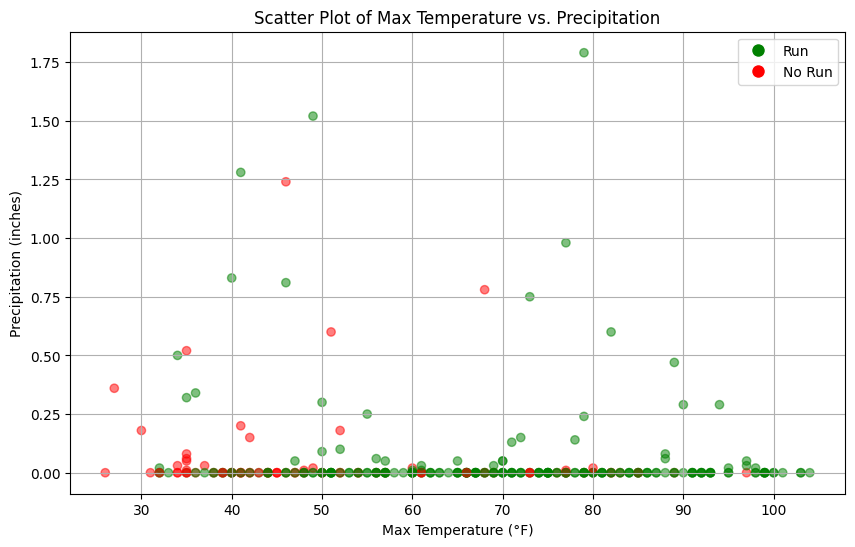

In [191]:
# Correct the column name in the DataFrame
data1['Day'] = pd.to_datetime(data1['Day'])

# Creating a scatter plot of TMAX vs PRCP with colors based on the 'Label' column
colors = ['red' if label == 0 else 'green' for label in data1['Label']]
plt.figure(figsize=(10, 6))
plt.scatter(data1['TMAX'], data1['PRCP'], color=colors, alpha=0.5)
plt.title('Scatter Plot of Max Temperature vs. Precipitation')
plt.xlabel('Max Temperature (°F)')
plt.ylabel('Precipitation (inches)')
plt.grid(True)

# Optional: Adding a legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Run',
                          markersize=10, markerfacecolor='green'),
                   Line2D([0], [0], marker='o', color='w', label='No Run',
                          markersize=10, markerfacecolor='red')]
plt.legend(handles=legend_elements)

plt.show()

Following I decided to implement the dropping of any rows that had  zero as precipitation, seeing that it seems that precipitation didn't play any factor as to why I decided to run that day or just go to the gym. By doing so, it does decrease the size of the data which was already depleted in the first place.

In [192]:
'''
DATA CLEANING AND DATA STRUCTURING
'''

#initiate label for all running workouts
data['Label'] = 0

for index, row in data.iterrows():
    if row['Exercise'] == 'Running':
        data.at[index,'Label'] = 1

#set up date times within the data
data['Date'] = pd.to_datetime(data['Date'])
data['Day'] = data['Date'].dt.strftime('%m/%d/%Y')

#drop unncessary columns
data1 = data.copy()
data1 = data1.drop(['Date', 'Exercise', 'Incline', 'Resistance', 'isWarmup', 'Note', 'multiplier'], axis=1)

columns = data1.columns.tolist()
new_order = ['Day'] + [col for col in columns if col != 'Day']
data1 = data1[new_order]

#initiate label and then group each day with the total sum of all the workouts
data1 = data1.groupby('Day').sum().reset_index()

# Since the user's 'Day' is in 'YYYY-MM-DD' format, we need to ensure the same format here
data1['Day'] = pd.to_datetime(data1['Day']).dt.strftime('%m/%d/%Y')
data1 = data1.sort_values(by='Day', ascending=True)
data1 = data1.reset_index(drop=True)

#Make all running labels binary so we can use them as labels
for index, row in data1.iterrows():
    if row['Label'] > 1:
        data1.at[index, 'Label'] = 1

#concatenate the two weather dataframes
dataweather = pd.concat([dataUT,dataMA], ignore_index=True)
dataweather['DATE'] = pd.to_datetime(dataweather['DATE']).dt.strftime('%m/%d/%Y')

#extract required dataweather set, join them to the workout dataframe on the date value, sort by day
selected_columns = dataweather[['PRCP', 'SNOW', 'SNWD', 'TMAX', 'DATE']]
data1 = pd.merge(data1, selected_columns, left_on='Day',right_on='DATE', how='left')
data1 = data1.drop(columns=['DATE'])
data1 = data1.dropna(how='any')
data1['Day'] = pd.to_datetime(data1['Day'], format='%m/%d/%Y')
data1 = data1.sort_values(by='Day')
data1 = data1.reset_index(drop=True)

#I didn't start running consistently until October 2020, so we are pulling data beginning then
data1 = data1[data1['Day'] >= '2020-10-01']
data1 = data1.drop(['Reps', 'Weight(kg)', 'Duration(s)', 'Distance(m)'], axis=1)


data1 = data1[data1['PRCP'] > 0]

x = data1[['PRCP', 'SNOW', 'SNWD', 'TMAX']]
y = data1[['Label']]
y = y.values.ravel()


In [193]:
'''
K-NN

Re-attempt with precipitation > 0
'''

kvalues = range(1, 21)  # Different k values for KNN
k_runs = {}

for k in kvalues:
    
    #Institute pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])

    # Perform cross-validation
    predictions = cross_val_predict(pipeline, x, y, cv=5)
    cm = confusion_matrix(y, predictions)

    accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')
    
    accuracy = accuracy_scores.mean()
    f1 = f1_scores.mean()

    k_runs[k] = (accuracy, cm, f1)

# Find the k value with the highest accuracy
best_k, (max_accuracy, max_cm, max_f1) = max(k_runs.items(), key=lambda item: item[1][0])

TN = max_cm[0,0]
FP = max_cm[0,1]
FN = max_cm[1,0]
TP = max_cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print(f'The K-value with highest accuracy is: {best_k}')

print('Confusion Matrix:')
print(max_cm)
print()
print(f'Accuracy: {max_accuracy * 100:.2f}%')
print(f'F1 Score: {max_f1 * 100:.2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')



The K-value with highest accuracy is: 16
Confusion Matrix:
[[10 10]
 [ 5 34]]

Accuracy: 74.85%
F1 Score: 81.49%
True Positive Rate:  87.18%
True Negative Rate:  50.00%


In [194]:
'''
Random Forest

Implemented loops to apply optimal hyperparameters
'''

n_estimators_range = range(1,31)
max_depth_range = range(1,31)
max_features_range = ['sqrt', 'log2']

# Variables to store the best model's metrics for the current random state
bestaccuracy = 0
best_hyperparams = {'n_estimators': 0, 'max_depth': None, 'max_features': None}
best_f1_score = 0
best_confusion_matrix = None
best_tpr = 0  
best_tnr = 0 

# Iterating through the range of n_estimators, max_depth, and max_features
for n_estimators in n_estimators_range:
    for max_depth in max_depth_range:
        for max_features in max_features_range:

            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, max_features=max_features))
            ])

            predictions = cross_val_predict(pipeline, x, y, cv=5)
            cm = confusion_matrix(y, predictions)
            accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
            f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')
            
            accuracy = accuracy_scores.mean()
            f1 = f1_scores.mean()
            

            # Evaluate the model
            if accuracy > bestaccuracy:
                bestaccuracy = accuracy
                best_hyperparams['n_estimators'] = n_estimators
                best_hyperparams['max_depth'] = max_depth
                best_hyperparams['max_features'] = max_features
                best_f1_score = f1_score(y, predictions)
                best_confusion_matrix = confusion_matrix(y, predictions)
                TN, FP, FN, TP = best_confusion_matrix.ravel()
                best_tpr = TP / (TP + FN)
                best_tnr = TN / (TN + FP)

# Display the results of the best model for the current random state

print("Best Hyperparameters")
print(f"Optimal N-Estimators: {best_hyperparams['n_estimators']}")
print(f"Optimal Max Depth: {best_hyperparams['max_depth']}")
print(f"Optimal Max Features: {best_hyperparams['max_features']}")
print()
print()
print("Confusion Matrix:\n", best_confusion_matrix)
print()
print(f'Accuracy:{bestaccuracy * 100: .2f}%')
print(f'F1: {best_f1_score * 100: .2f}%')
print(f'True Positive Rate: {best_tpr * 100: .2f}%')
print(f'True Negative Rate: {best_tnr * 100: .2f}%')
print("\n")


Best Hyperparameters
Optimal N-Estimators: 8
Optimal Max Depth: 30
Optimal Max Features: sqrt


Confusion Matrix:
 [[12  8]
 [14 25]]

Accuracy: 78.18%
F1:  69.44%
True Positive Rate:  64.10%
True Negative Rate:  60.00%




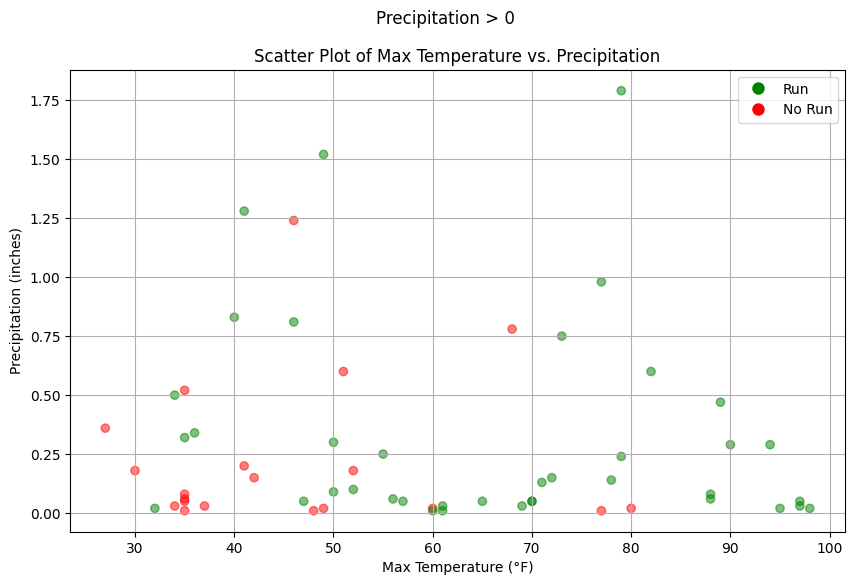

In [195]:
'''
Plotting Data

Temperature and Precipiation
'''

# Correct the column name in the DataFrame
data1['Day'] = pd.to_datetime(data1['Day'])

# Creating a scatter plot of TMAX vs PRCP with colors based on the 'Label' column
colors = ['red' if label == 0 else 'green' for label in data1['Label']]
plt.figure(figsize=(10, 6))
plt.scatter(data1['TMAX'], data1['PRCP'], color=colors, alpha=0.5)
plt.title('Scatter Plot of Max Temperature vs. Precipitation')
plt.suptitle('Precipitation > 0')
plt.xlabel('Max Temperature (°F)')
plt.ylabel('Precipitation (inches)')
plt.grid(True)

# Adding legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Run',
                          markersize=10, markerfacecolor='green'),
                   Line2D([0], [0], marker='o', color='w', label='No Run',
                          markersize=10, markerfacecolor='red')]
plt.legend(handles=legend_elements)

plt.show()

In [196]:
'''
LOGISTIC REGRESSION MODEL

ATTEMPT #2

'''

# Initiate and train the logistic regression model
pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression())
    ])

# Perform cross-validation
predictions = cross_val_predict(pipeline, x, y, cv=5)
cm = confusion_matrix(y, predictions)

accuracy_scores = cross_val_score(pipeline, x, y, cv=5, scoring='accuracy')
f1_scores = cross_val_score(pipeline, x, y, cv=5, scoring='f1')

accuracy = accuracy_scores.mean()
f1 = f1_scores.mean()

# Print results
print("Confusion Matrix:\n", cm)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
print()
print(f'Accuracy:{accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[14  6]
 [ 5 34]]

Accuracy: 81.52%
F1:  85.74%
True Positive Rate:  87.18%
True Negative Rate:  70.00%


In [198]:
a = data1[['SNOW', 'SNWD', 'TMAX']]
b = data1[['Label']]
b = b.values.ravel()


In [201]:
'''
LOGISTIC REGRESSION MODEL

Attempt #3 (without precipitation)

'''

# Initiate and train the logistic regression model
pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression())
    ])

# Perform cross-validation
predictions = cross_val_predict(pipeline, a, b, cv=5)
cm = confusion_matrix(y, predictions)

accuracy_scores = cross_val_score(pipeline, a, b, cv=5, scoring='accuracy')
f1_scores = cross_val_score(pipeline, a, b, cv=5, scoring='f1')


f1 = f1_scores.mean()

# Print results
print("Confusion Matrix:\n", cm)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
print()
print(f'Accuracy:{accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[13  7]
 [ 6 33]]

Accuracy: 77.97%
F1:  82.89%
True Positive Rate:  84.62%
True Negative Rate:  65.00%


In [200]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='linear'))  # You can change the kernel as needed
])

# Perform cross-validation
predictions = cross_val_predict(pipeline, a, b, cv=5)
cm = confusion_matrix(b, predictions)  # Ensure you use 'b' for true labels in confusion matrix

# Calculate scores
accuracy_scores = cross_val_score(pipeline, a, b, cv=5, scoring='accuracy')
f1_scores = cross_val_score(pipeline, a, b, cv=5, scoring='f1_macro')  # Use 'f1_macro' for multi-class

# Calculate mean F1 score
f1 = f1_scores.mean()

# Print results
print("Confusion Matrix:\n", cm)

# Extract confusion matrix components
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

# Calculate rates
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Print performance metrics
print(f'Accuracy: {accuracy * 100: .2f}%')
print(f'F1: {f1 * 100: .2f}%')
print(f'True Positive Rate: {TPR * 100: .2f}%')
print(f'True Negative Rate: {TNR * 100: .2f}%')

Confusion Matrix:
 [[10 10]
 [ 6 33]]
Accuracy:  72.88%
F1:  66.29%
True Positive Rate:  84.62%
True Negative Rate:  50.00%


The question at hand, is how do I want the results? What answers do I want to glean from the predictions? Do I want to to be correct when I predict a 'Run' or do I want to be as correct as possible for both TPR and TNR?